In [ ]:
if "BrentScheme" not in locals():
  !pip install "git+https://github.com/perryGabriel/brent-scheme.git"
from brentscheme import *
import torch
from tqdm import trange
import time


factory = SchemaFactory()
printer = SchemeDisplay()
manipulator = SchemeManipulator()
stepper = Stepper()
trainer = Trainer()

In [ ]:
# printer.dump_tensors(scheme)

# Find the 2,2,2,6 scheme


  0%|          | 0/1000 [00:00<?, ?it/s]

[1.3201628365093345, 1.606540153903603, 5.2841434135734096]


  0%|          | 0/1000 [00:09<?, ?it/s]


Scheme for (2×2) @ (2×2) using p=6 out of 8 products; complexity n^2.585
Norm: L1 over field None
Avg L1 error: 10^-0.8327, Avg L2 error: 10^-0.7394, Max error: 10^-0.2999

Products P_i = (alpha_i · A) * (beta_i · B)
P_1 = ( 1.183*A[1,1] +  1.286*A[1,2] +  0.373*A[2,1] +  1.444*A[2,2]) * ( 1.039*B[1,1] + -0.099*B[1,2] + -2.191*B[2,1] +  2.030*B[2,2])
P_2 = ( 2.534*A[1,1] +  1.526*A[1,2] + -0.231*A[2,1] + -0.698*A[2,2]) * (-0.195*B[1,1] + -0.960*B[1,2] +  0.449*B[2,1] + -0.375*B[2,2])
P_3 = ( 0.812*A[1,1] +  0.375*A[1,2] +  1.081*A[2,1] + -0.213*A[2,2]) * ( 0.321*B[1,1] + -1.663*B[1,2] + -0.106*B[2,1] +  0.428*B[2,2])
P_4 = (-3.134*A[1,1] + -0.023*A[1,2] + -0.259*A[2,1] + -1.548*A[2,2]) * (-1.206*B[1,1] +  0.253*B[1,2] +  0.714*B[2,1] + -0.681*B[2,2])
P_5 = ( 0.131*A[1,1] +  1.166*A[1,2] +  0.265*A[2,1] + -0.542*A[2,2]) * (-0.165*B[1,1] +  0.451*B[1,2] + -0.738*B[2,1] + -0.737*B[2,2])
P_6 = (-1.568*A[1,1] + -1.232*A[1,2] + -2.275*A[2,1] + -0.809*A[2,2]) * ( 1.499*B[1,1] + -0.213*B[1,2] 

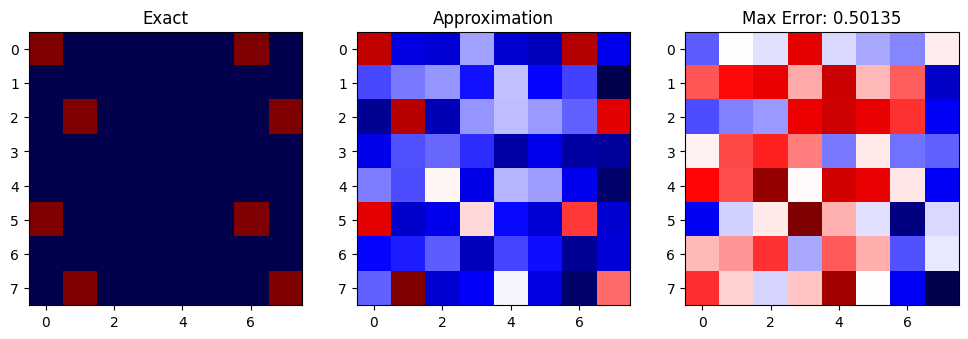

[0.14697848284078588, 0.18223991259982292, 0.5013508101394519]


In [ ]:
scheme = BrentScheme(n=2,d=2,m=2,p=6)
manipulator.set_norm(scheme, norm=1)

from tqdm import trange
try:
  for i in trange(1000):
    if i % 30 == 0:
      print([10**printer.metrics(scheme).log10_L1,10**printer.metrics(scheme).log10_L2,10**printer.metrics(scheme).log10_Linf])
    if 10**printer.metrics(scheme).log10_L2 < 0.1251:
      break
    # enforce_known(scheme)
    try:
      stepper.optimize(scheme, batch_size=2)
    except KeyboardInterrupt:
      break
    except:
      pass
    stepper.epoch_pseudoinverse(scheme, batch_size=2)
    stepper.epoch(scheme, penalty=0.2, lr=5e-5, batch_size=2)
    manipulator.normalize(scheme)
except:
  pass

printer.report(scheme, verbose=2)
printer.plot_triple_deltas(scheme)
print([10**printer.metrics(scheme).log10_L1,10**printer.metrics(scheme).log10_L2,10**printer.metrics(scheme).log10_Linf])

In [ ]:
import numpy as np

def enforce_known(scheme):
  target_slice = scheme.alpha_pnd[5, :, :]
  for i in range(target_slice.shape[0]):
      for j in range(target_slice.shape[1]):
          element = target_slice[i, j]
          scheme.alpha_pnd[5, i, j] = 0.5 * torch.sign(element)

  target_slice = scheme.beta__pdm[5, :, :]
  for i in range(target_slice.shape[0]):
      for j in range(target_slice.shape[1]):
          element = target_slice[i, j]
          scheme.beta__pdm[5, i, j] = 0.5 * torch.sign(element)

  target_slice = scheme.gamma_nmp[:, :, 5]
  for i in range(target_slice.shape[0]):
      for j in range(target_slice.shape[1]):
          element = target_slice[i, j]
          scheme.gamma_nmp[i, j, 5] = 0.5 * torch.sign(element)

  # print(scheme.gamma_nmp[:, :, 5])

# Code used to train 3,3,3,22 scheme with $10^{-3}$ error

In [ ]:
#@title Normalize the scheme, retrain to converge toward a normalized fixed point

manipulator.set_norm(scheme, np.inf)
for i in range(5):
  scores = printer.test(scheme, verbose=1)

  if scores[1] < -3.13 and scores[2] <-2.63:
    manipulator.set_norm(scheme, 2)
    score = printer.dump_to_file(scheme)
    print(f"Score: {score}")
    download_file(n=scheme.n, d=scheme.d, m=scheme.m, p=scheme.p, number=score, scheme_or_diagram='scheme')
    break

  if i % 10 == 0:
    # print()
    printer.test(scheme,verbose=2)
  L,M,R = trainer.optimize_basis(scheme, batch_size=230, lr=4e-6) # mostly preserves Frobenius - needs a good lr (too big = overstep, too small = can't overcome other steps)
  manipulator.change_basis(scheme, L=L, M=M, R=R)
  # stepper.epoch(scheme, batch_size=100, lr=1e-10, momentum=0.999)
  manipulator.normalize(scheme, verbose=0) # THIS CHANGE OF BASIS DOES NOT PRESERVE FROBENIUS BUT DOES PRESERVE SOMETHING?
  stepper.epoch_pseudoinverse(scheme, batch_size=205)
manipulator.set_norm(scheme, np.inf)
manipulator.normalize(scheme, verbose=1)
printer.print(scheme, verbose=2)
printer.print_triple_deltas(scheme)

# Basis Function Playground SCHEME IS NOT VALID

In [ ]:
scheme = BrentScheme(n=2, p=4)

In [ ]:
def set_Perry(scheme, n=None, w=None, verbose=0):
  if n is None:
    n = scheme.n

  if w is None:
    root_num = int(np.power(2, 4*np.ceil(np.log2(n))))
    w = np.exp(2 * 3.141592653589793238462643383279502884197j / root_num)
    use_numpy = False
  else:
    root_num = n**4
    use_numpy = True
  p = int(root_num**1/2)
  scheme = BrentScheme(n=n,d=n,m=n, p=p)

  if verbose:
    assert (n**3, np.power(w, n**3).round(5) == -1+0j), "w was not a root of unity"

  if use_numpy:
    scheme.alpha_pnd = np.fromfunction(lambda p, a, A: w**(p*(a*n**3+A*n**2)), (scheme.p, scheme.n, scheme.n), dtype=complex)
    scheme.beta__pdm = np.fromfunction(lambda p, b, B:  w**(p*(b*n+B)), (scheme.p, scheme.n, scheme.n), dtype=complex)
    scheme.gamma_nmp = np.fromfunction(lambda p, a, A, b, B:  w**(-p*(a*n**3+A*n**2+b*n+B)), (scheme.p, scheme.n, scheme.n, scheme.n, scheme.n), dtype=complex)
    scheme.gamma_nmp = np.einsum("pakkB->aBp", scheme.gamma_nmp)/(n) # * 2pi)
  else:
    scheme.alpha_pnd = torch.from_numpy(np.fromfunction(lambda p, a, A: w**(p*(a*n**3+A*n**2)), (scheme.p, scheme.n, scheme.n), dtype=complex))
    scheme.beta__pdm = torch.from_numpy(np.fromfunction(lambda p, b, B:  w**(p*(b*n+B)), (scheme.p, scheme.n, scheme.n), dtype=complex))
    scheme.gamma_nmp = np.fromfunction(lambda p, a, A, b, B:  w**(-p*(a*n**3+A*n**2+b*n+B)), (scheme.p, scheme.n, scheme.n, scheme.n, scheme.n), dtype=complex)
    scheme.gamma_nmp = torch.from_numpy(np.einsum("pakkB->aBp", scheme.gamma_nmp)/(n)) # * 2pi)

  return scheme

<>:16: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:16: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/tmp/ipython-input-355827895.py:16: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (n**3, np.power(w, n**3).round(5) == -1+0j), "w was not a root of unity"


In [ ]:
scheme = set_Perry(scheme, n=2, verbose = 1)
printer.report(scheme, verbose=2)

Scheme for (2×2) @ (2×2) using p=8 out of 8 products; complexity n^3.000
Norm: L2 over field R
Avg L1 error: 10^0.1134, Avg L2 error: 10^0.2474, Max error: 10^0.4771

Products P_i = (alpha_i · A) * (beta_i · B)
P_1 = ( 1.000+0.000j*A[1,1] +  1.000+0.000j*A[1,2] +  1.000+0.000j*A[2,1] +  1.000+0.000j*A[2,2]) * ( 1.000+0.000j*B[1,1] +  1.000+0.000j*B[1,2] +  1.000+0.000j*B[2,1] +  1.000+0.000j*B[2,2])
P_2 = ( 1.000+0.000j*A[1,1] + -0.000+1.000j*A[1,2] + -1.000-0.000j*A[2,1] +  0.000-1.000j*A[2,2]) * ( 1.000+0.000j*B[1,1] +  0.924+0.383j*B[1,2] +  0.707+0.707j*B[2,1] +  0.383+0.924j*B[2,2])
P_3 = ( 1.000+0.000j*A[1,1] + -1.000-0.000j*A[1,2] +  1.000+0.000j*A[2,1] + -1.000-0.000j*A[2,2]) * ( 1.000+0.000j*B[1,1] +  0.707+0.707j*B[1,2] + -0.000+1.000j*B[2,1] + -0.707+0.707j*B[2,2])
P_4 = ( 1.000+0.000j*A[1,1] +  0.000-1.000j*A[1,2] + -1.000-0.000j*A[2,1] + -0.000+1.000j*A[2,2]) * ( 1.000+0.000j*B[1,1] +  0.383+0.924j*B[1,2] + -0.707+0.707j*B[2,1] + -0.924-0.383j*B[2,2])
P_5 = ( 1.000+0.000j*

In [ ]:
# Handles symbolic powers of w within SymPy expressions.
# Specifically, it applies a modulo operation to the exponent of w if w is the base of a power.
# This is useful when w represents a root of unity, and its powers cycle after a certain modulus
def mod_power(expr, n):
  if isinstance(expr, sympy.Pow) and expr.base == sympy.Symbol('w'):
    return sympy.Symbol('w')**(expr.exp % n**4)
  elif isinstance(expr, sympy.Mul):
    new_args = []
    for arg in expr.args:
      new_args.append(mod_power(arg, n))
    return sympy.Mul(*new_args)
  elif isinstance(expr, sympy.Add):
    new_args = []
    for arg in expr.args:
      new_args.append(mod_power(arg, n))
    return sympy.Add(*new_args)
  else:
    return expr

# Simplify the roots of unity in the expression
n = scheme.n
import sympy
scheme = set_Perry(scheme, n=None, w=sympy.Symbol('w'))
alpha = sympy.Matrix(scheme.alpha_pnd.reshape(scheme.p,scheme.n**2))
for i,row in enumerate(alpha.tolist()):
  for j, elem in enumerate(row):
    alpha[i,j] = mod_power(elem, n)
scheme.alpha_pnd = np.array(alpha).reshape(scheme.p, scheme.n, scheme.n)

beta = sympy.Matrix(scheme.beta__pdm.reshape(scheme.p,scheme.n**2))
for i,row in enumerate(beta.tolist()):
  for j, elem in enumerate(row):
    beta[i,j] = mod_power(elem, n)
scheme.beta__pdm = np.array(beta).reshape(scheme.p, scheme.n, scheme.n)

gamma = sympy.Matrix(scheme.gamma_nmp.reshape(scheme.n**2,scheme.p))
for i,row in enumerate(gamma.tolist()):
  for j, elem in enumerate(row):
    gamma[i,j] = mod_power(elem, n)
scheme.gamma_nmp = np.array(gamma).reshape(scheme.n, scheme.n, scheme.p)

In [ ]:
triple_delta = np.einsum("cCp,paA,pbB->aAbBcC",scheme.gamma_nmp,scheme.alpha_pnd,scheme.beta__pdm)
# w = np.exp(2 * 3.141592653589793238462643383279502884197j / scheme.n**4)
mod_power(sympy.Matrix(triple_delta[0,:,0,0,1,:]),n)
# mod_power(mod_power(sympy.Matrix(triple_delta[0,:,0,0,1,:]),2).applyfunc(lambda x: x.simplify()),2).applyfunc(lambda x: x.simplify())

Matrix([
[                                                                                                              w**2.0/2 + w**4.0/2 + w**6.0/2 + 5*w**8.0/2 + w**10.0/2 + w**12.0/2 + w**14.0/2 + 5/2,                                                                                                             w**1.0 + w**2.0/2 + w**3.0 + w**4.0/2 + w**5.0 + w**6.0/2 + w**7.0 + w**10.0/2 + w**12.0/2 + w**14.0/2 + 1],
[w**4.0*(w**2.0/2 + w**8.0/2) + w**4.0*(w**8.0/2 + w**10.0/2) + w**8.0*(w**4.0/2 + 1/2) + w**8.0*(w**12.0/2 + 1/2) + w**8.0/2 + w**12.0*(w**6.0/2 + w**8.0/2) + w**12.0*(w**8.0/2 + w**14.0/2) + 3/2, w**4.0*(w**1.0/2 + w**7.0/2) + w**4.0*(w**3.0/2 + w**5.0/2) + w**4.0/2 + w**8.0*(w**2.0/2 + w**14.0/2) + w**8.0*(w**6.0/2 + w**10.0/2) + w**12.0*(w**1.0/2 + w**7.0/2) + w**12.0*(w**3.0/2 + w**5.0/2) + w**12.0/2 + 1]])